# HGBR — Vizualizáció

**Felelős:** Vass Levente

Ez a notebook **csak vizualizál**. A `05_hgbr.ipynb` által Drive-ra mentett artefaktokat olvassa be:
- `hgbr_tuned.joblib` (TransformedTargetRegressor wrapper a HGBR + log-target köré)
- `hgbr_predictions_test.npy`
- `hgbr_validation_curve_max_leaf_nodes.npz`
- `hgbr_learning_curve.npz`

+ a `data_io.load_v1_data()`-ból a `y_train`, `y_test`, `X_test`, `feature_names`.

Sklearn fitmentes (kivéve a permutation-importance-t a feature importance-hoz, ami egy 50k-s teszt-mintán fut).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Slityak/gepitan-seoul-bike-trip/blob/main/notebooks/05_hgbr_visualize.ipynb)

## 1. Setup (Colab + lokális kompatibilis)

In [1]:
import os
import sys

IN_COLAB = 'google.colab' in sys.modules
BRANCH = 'main'

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    if not os.path.exists('/content/gepitan-beadando'):
        !git clone --branch {BRANCH} https://github.com/Slityak/gepitan-seoul-bike-trip.git /content/gepitan-beadando

    os.chdir('/content/gepitan-beadando')
    !git fetch origin {BRANCH}
    !git checkout {BRANCH}
    !git pull origin {BRANCH}
    !pip install -q -r requirements.txt
else:
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')

sys.path.insert(0, '.')
print(f'Working dir: {os.getcwd()}')
print(f'In Colab: {IN_COLAB}')
print(f'Branch: {BRANCH}')

Mounted at /content/drive
Cloning into '/content/gepitan-beadando'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 117 (delta 70), reused 89 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 126.02 KiB | 2.47 MiB/s, done.
Resolving deltas: 100% (70/70), done.
From https://github.com/Slityak/gepitan-seoul-bike-trip
 * branch            main       -> FETCH_HEAD
Already on 'main'
Your branch is up to date with 'origin/main'.
From https://github.com/Slityak/gepitan-seoul-bike-trip
 * branch            main       -> FETCH_HEAD
Already up to date.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.5 MB/s eta 0:00:00
Working dir: /content/gepitan-beadando
In Colab: True
Branch: main


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import joblib

from src.config import MODELS_DIR, FIGURES_DIR, RANDOM_SEED, ensure_dirs
from src.data_io import load_v1_data
from src.visualization import (
    plot_error_by_feature_quantile,
    plot_feature_importance,
    plot_learning_curve,
    plot_predicted_vs_actual,
    plot_residuals,
    plot_target_distribution,
    plot_validation_curve,
)

ensure_dirs()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Adatok és mentett artefaktok betöltése

In [3]:
X_train, X_test, y_train, y_test, feature_names = load_v1_data()

best_model = joblib.load(MODELS_DIR / 'hgbr_tuned.joblib')
y_pred_tuned = np.load(MODELS_DIR / 'hgbr_predictions_test.npy')
vc = np.load(MODELS_DIR / 'hgbr_validation_curve_max_leaf_nodes.npz')
lc = np.load(MODELS_DIR / 'hgbr_learning_curve.npz')

# A best_model egy TransformedTargetRegressor — a belső HGBR a .regressor_ attribútumon keresztül érhető el
hgbr = best_model.regressor_

print(f'best_model: {type(best_model).__name__} → {type(hgbr).__name__}')
print(f'HGBR n_iter_ (tényleges iterációk early stopping miatt): {hgbr.n_iter_}')
print(f'y_pred_tuned shape: {y_pred_tuned.shape}')
print(f'validation curve: {len(vc["param_range_labels"])} max_leaf_nodes érték')
print(f'learning curve:   {len(lc["sizes"])} train size pont')

best_model: TransformedTargetRegressor → HistGradientBoostingRegressor
HGBR n_iter_ (tényleges iterációk early stopping miatt): 700
y_pred_tuned shape: (1920228,)
validation curve: 5 max_leaf_nodes érték
learning curve:   8 train size pont


## 3. Predicted vs actual

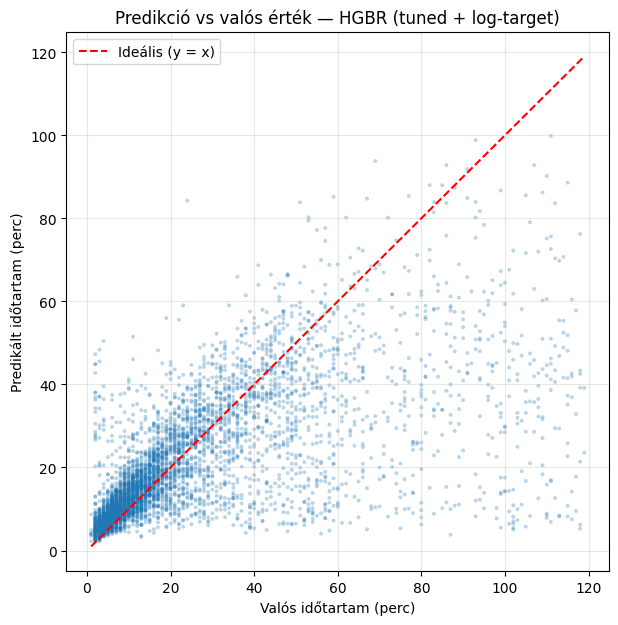

In [4]:
plot_predicted_vs_actual(
    y_test, y_pred_tuned,
    model_name='HGBR (tuned + log-target)',
    save_path='hgbr_predicted_vs_actual.png',
)
plt.show()

## 4. Residuals

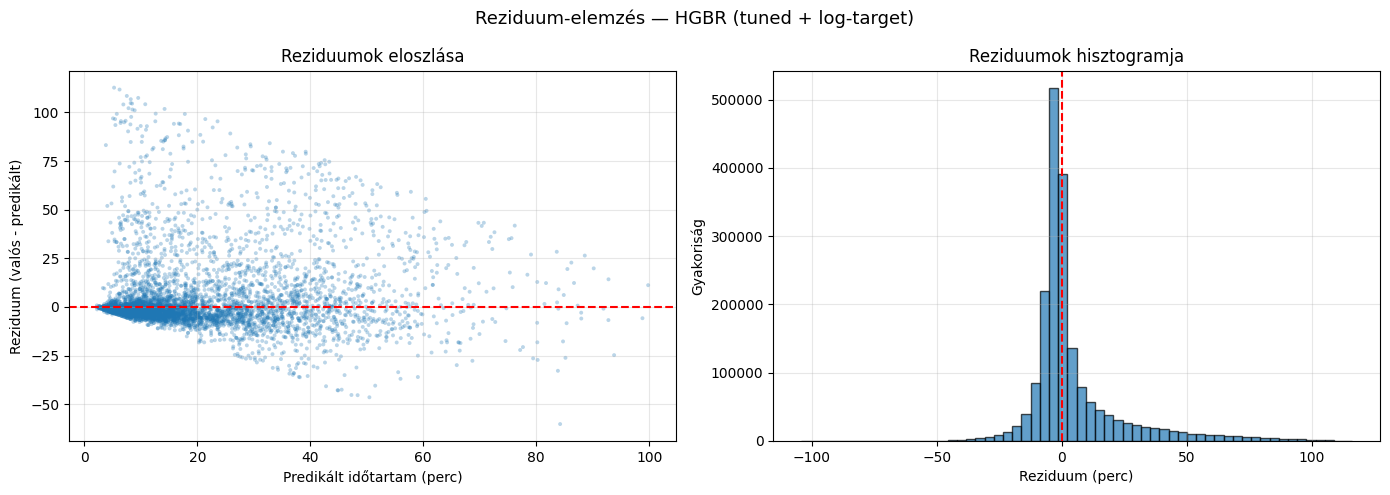

In [5]:
plot_residuals(
    y_test, y_pred_tuned,
    model_name='HGBR (tuned + log-target)',
    save_path='hgbr_residuals.png',
)
plt.show()

## 5. Feature importance (permutation importance)

A `HistGradientBoostingRegressor`-nak nincs natív `feature_importances_` attribútuma, ezért **permutation importance**-szel mérjük: minden feature-t véletlenszerűen összekeverünk és megnézzük, mennyit romlik a modell teszt MAE-je. Ami sok romlással jár → fontos. Sample-en fut (50k), különben nagyon lassú lenne.

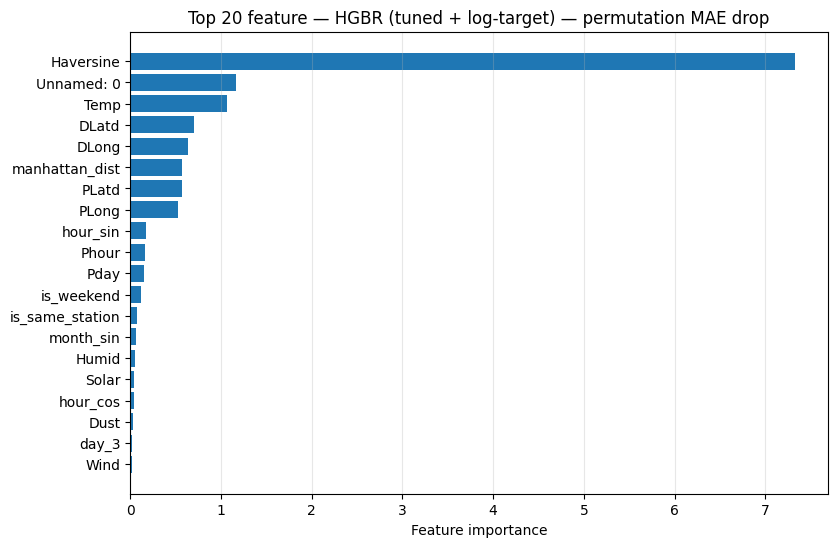

In [6]:
from sklearn.inspection import permutation_importance

PERM_SAMPLE_SIZE = 50_000
rng = np.random.default_rng(RANDOM_SEED)
perm_idx = rng.choice(len(X_test), size=min(PERM_SAMPLE_SIZE, len(X_test)), replace=False)
X_perm, y_perm = X_test[perm_idx], y_test[perm_idx]

perm = permutation_importance(
    best_model, X_perm, y_perm,
    n_repeats=3,
    scoring='neg_mean_absolute_error',
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

plot_feature_importance(
    feature_names=feature_names,
    importances=perm.importances_mean,
    model_name='HGBR (tuned + log-target) — permutation MAE drop',
    top_n=20,
    save_path='hgbr_feature_importance.png',
)
plt.show()

## 6. Validation curve (max_leaf_nodes)

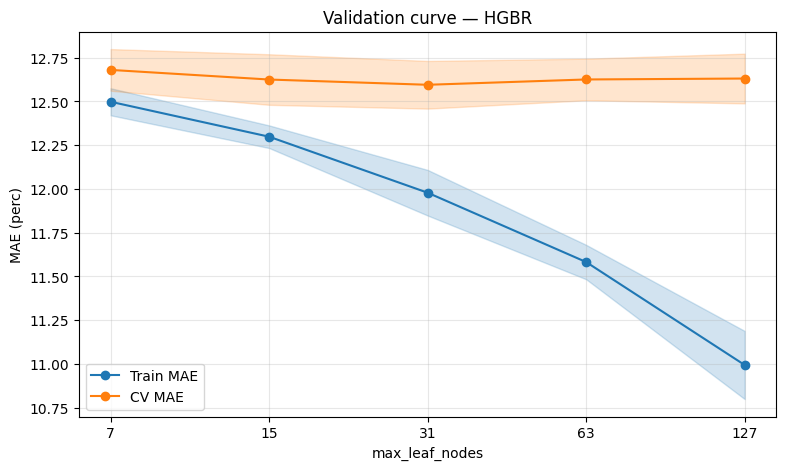

In [7]:
plot_validation_curve(
    param_range_labels=list(vc['param_range_labels']),
    train_mae=vc['train_mae'],
    test_mae=vc['test_mae'],
    param_name='max_leaf_nodes',
    model_name='HGBR',
    save_path='hgbr_validation_curve_max_leaf_nodes.png',
)
plt.show()

## 7. Learning curve

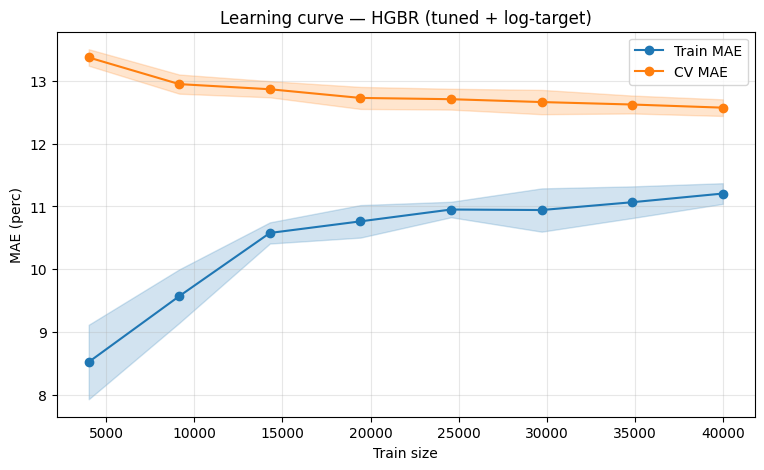

In [8]:
plot_learning_curve(
    sizes=lc['sizes'],
    train_mae=lc['train_mae'],
    test_mae=lc['test_mae'],
    model_name='HGBR (tuned + log-target)',
    save_path='hgbr_learning_curve.png',
)
plt.show()

## 8. Hiba feature szerint

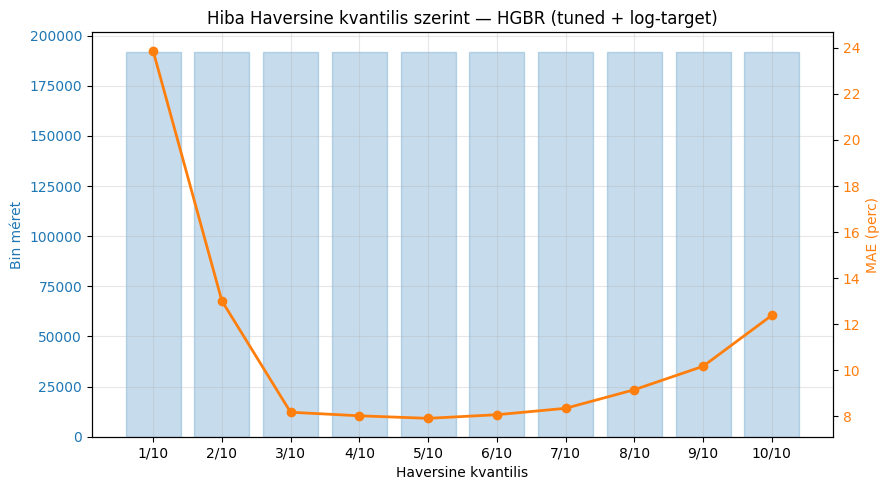

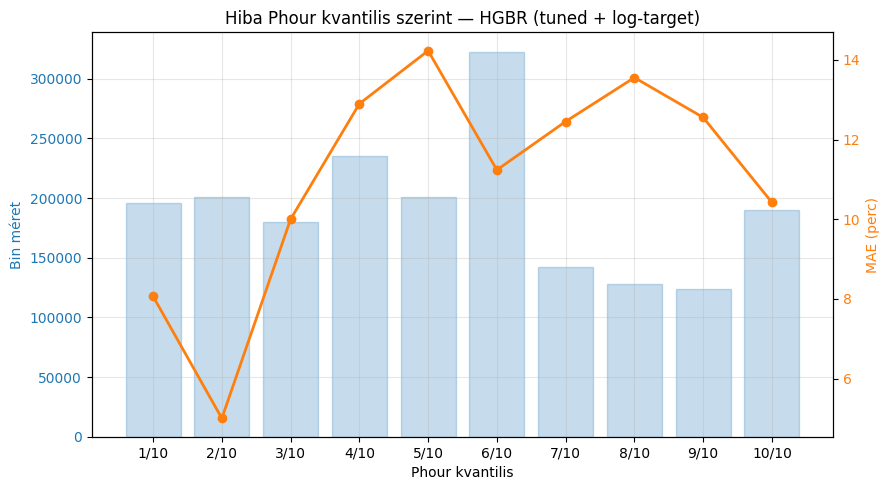

In [9]:
hav_idx = feature_names.index('Haversine')
plot_error_by_feature_quantile(
    y_test, y_pred_tuned, X_test[:, hav_idx],
    feature_name='Haversine',
    n_bins=10,
    model_name='HGBR (tuned + log-target)',
    save_path='hgbr_error_by_haversine.png',
)
plt.show()

phour_idx = feature_names.index('Phour')
plot_error_by_feature_quantile(
    y_test, y_pred_tuned, X_test[:, phour_idx],
    feature_name='Phour',
    n_bins=10,
    model_name='HGBR (tuned + log-target)',
    save_path='hgbr_error_by_phour.png',
)
plt.show()

## 9. Boosting iteráció görbe (HGBR-specifikus)

A `HistGradientBoostingRegressor` `early_stopping=True` mellett iterációnként méri a train és validation loss-t. Az alábbi ábra megmutatja, hogyan csökkent a hiba a 700 iteráció alatt — és hogy az early stopping mikor állította le a tanítást (n_iter_).

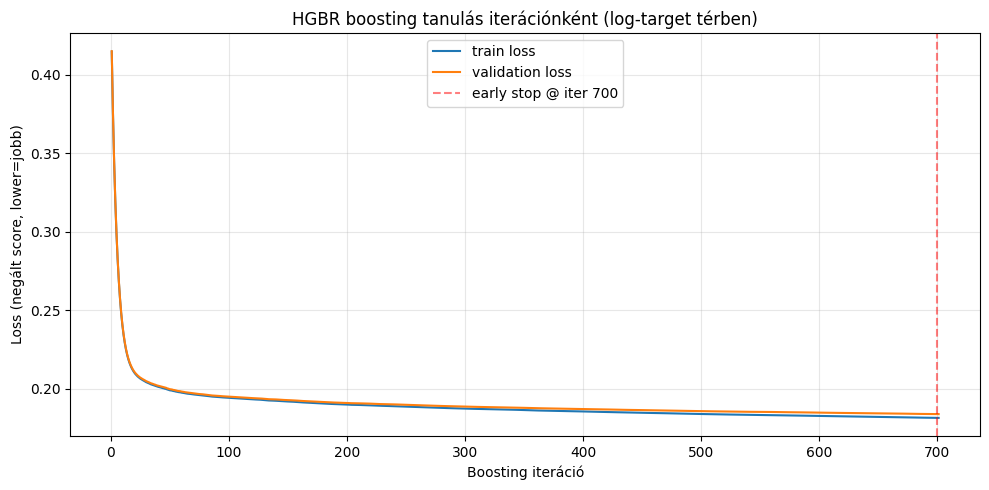

Tényleges iterációszám (early stopping miatt): 700 (max_iter konfigurálva: 700)


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
iters = np.arange(1, len(hgbr.train_score_) + 1)
ax.plot(iters, -hgbr.train_score_, label='train loss', linewidth=1.5)
if hasattr(hgbr, 'validation_score_') and hgbr.validation_score_ is not None:
    ax.plot(iters, -hgbr.validation_score_, label='validation loss', linewidth=1.5)
ax.axvline(hgbr.n_iter_, color='red', linestyle='--', alpha=0.5, label=f'early stop @ iter {hgbr.n_iter_}')
ax.set_xlabel('Boosting iteráció')
ax.set_ylabel('Loss (negált score, lower=jobb)')
ax.set_title('HGBR boosting tanulás iterációnként (log-target térben)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'hgbr_boosting_iterations.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Tényleges iterációszám (early stopping miatt): {hgbr.n_iter_} (max_iter konfigurálva: {hgbr.max_iter})')